In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
data = pd.read_csv('../source/player1.csv')
data.head()

,match_id,kills,damage,placement,survival_time,headshots,win
0,1,2.0,185.0,23.0,12,0.0,0
1,2,5.0,640.0,7.0,24,2.0,0
2,3,0.0,35.0,89.0,3,0.0,0
3,4,7.0,890.0,2.0,28,3.0,0
4,5,3.0,310.0,14.0,19,1.0,0


In [6]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   match_id       40 non-null     int64  
 1   kills          39 non-null     float64
 2   damage         39 non-null     float64
 3   placement      39 non-null     float64
 4   survival_time  40 non-null     int64  
 5   headshots      39 non-null     float64
 6   win            40 non-null     int64  
dtypes: float64(4), int64(3)
memory usage: 2.3 KB


,match_id,kills,damage,placement,survival_time,headshots,win
count,40.000000,39.000000,39.000000,39.000000,40.000000,39.000000,40.000000
mean,20.500000,29.615385,607.051282,22.923077,18.675000,2.000000,0.075000
std,11.690452,159.346134,850.986825,24.922390,8.434932,2.328315,0.266747
min,1.000000,-1.000000,0.000000,1.000000,2.000000,0.000000,0.000000
25%,10.750000,2.000000,187.500000,6.000000,12.750000,1.000000,0.000000
50%,20.500000,3.000000,380.000000,14.000000,19.500000,1.000000,0.000000
75%,30.250000,6.000000,710.000000,28.500000,25.000000,2.500000,0.000000
max,40.000000,999.000000,5000.000000,95.000000,33.000000,12.000000,1.000000


In [7]:
data.isnull().sum()

match_id         0
kills            1
damage           1
placement        1
survival_time    0
headshots        1
win              0
dtype: int64

In [8]:
num_cols = ['kills', 'damage', 'placement', 'survival_time', 'headshots']
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)
data.isnull().sum()

C:\Users\SSbee\AppData\Local\Temp\ipykernel_18444\1665539113.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data[col].fillna(data[col].median(), inplace=True)
C:\Users\SSbee\AppData\Local\Temp\ipykernel_18444\1665539113.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

match_id         0
kills            1
damage           1
placement        1
survival_time    0
headshots        1
win              0
dtype: int64

In [9]:
data[['kills','damage','placement','survival_time','headshots']].describe()

,kills,damage,placement,survival_time,headshots
count,39.000000,39.000000,39.000000,40.000000,39.000000
mean,29.615385,607.051282,22.923077,18.675000,2.000000
std,159.346134,850.986825,24.922390,8.434932,2.328315
min,-1.000000,0.000000,1.000000,2.000000,0.000000
25%,2.000000,187.500000,6.000000,12.750000,1.000000
50%,3.000000,380.000000,14.000000,19.500000,1.000000
75%,6.000000,710.000000,28.500000,25.000000,2.500000
max,999.000000,5000.000000,95.000000,33.000000,12.000000


In [10]:
data['kills'] = data['kills'].apply(lambda x: max(x,0))
data['damage'] = data['damage'].apply(lambda x: max(x,0))
data['placement'] = data['placement'].apply(lambda x: max(x,1))
data['survival_time'] = data['survival_time'].apply(lambda x: max(x,1))
data['headshots'] = data['headshots'].apply(lambda x: max(x,0))

In [11]:
for col in ['kills','damage','survival_time','headshots']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    data[col] = np.where(data[col] > upper, upper, data[col])
    data[col] = np.where(data[col] < lower, lower, data[col])

In [13]:
data.to_csv('../outputs/cleaned_data.csv', index=False)

In [14]:
avg_kills = data['kills'].mean()
avg_damage = data['damage'].mean()
print(f"Average kills per match: {avg_kills:.2f}")
print(f"Average damage per match: {avg_damage:.2f}")

Average kills per match: 4.26
Average damage per match: 499.04


In [15]:
if 'win' in data.columns:
    win_rate = data['win'].mean()
    print(f"Win rate: {win_rate*100:.2f}%")

Win rate: 7.50%


In [16]:
corr = data.corr()
corr

,match_id,kills,damage,placement,survival_time,headshots,win
match_id,1.000000,-0.048687,-0.021991,0.011392,0.008191,0.004117,-0.127449
kills,-0.048687,1.000000,0.993407,-0.734979,0.923006,0.974950,0.676810
damage,-0.021991,0.993407,1.000000,-0.699855,0.908102,0.970735,0.677557
placement,0.011392,-0.734979,-0.699855,1.000000,-0.901357,-0.725177,-0.257254
survival_time,0.008191,0.923006,0.908102,-0.901357,1.000000,0.912170,0.455557
headshots,0.004117,0.974950,0.970735,-0.725177,0.912170,1.000000,0.599451
win,-0.127449,0.676810,0.677557,-0.257254,0.455557,0.599451,1.000000


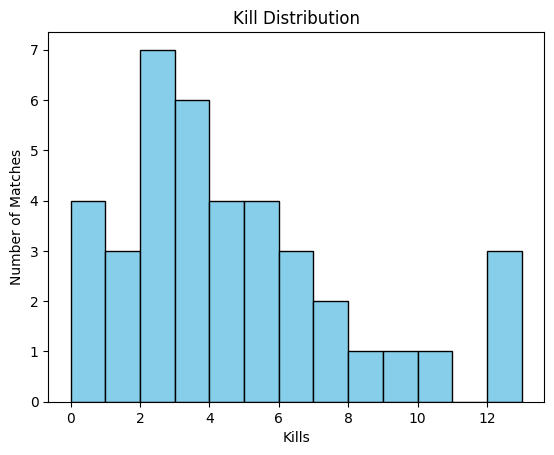

In [17]:
plt.hist(data['kills'], bins=range(0,int(data['kills'].max())+2), color='skyblue', edgecolor='black')
plt.title('Kill Distribution')
plt.xlabel('Kills')
plt.ylabel('Number of Matches')
plt.show()

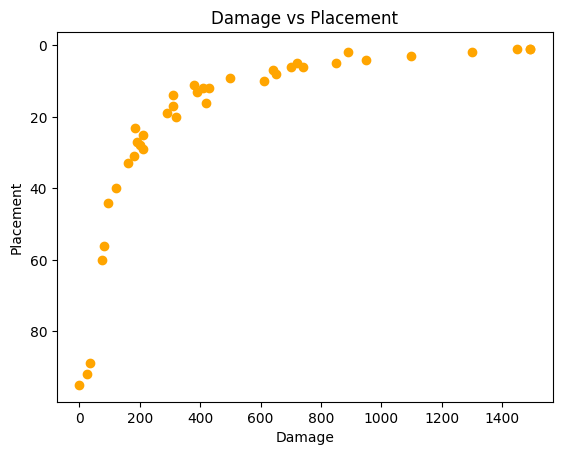

In [18]:
plt.scatter(data['damage'], data['placement'], color='orange')
plt.title('Damage vs Placement')
plt.xlabel('Damage')
plt.ylabel('Placement')
plt.gca().invert_yaxis()
plt.show()

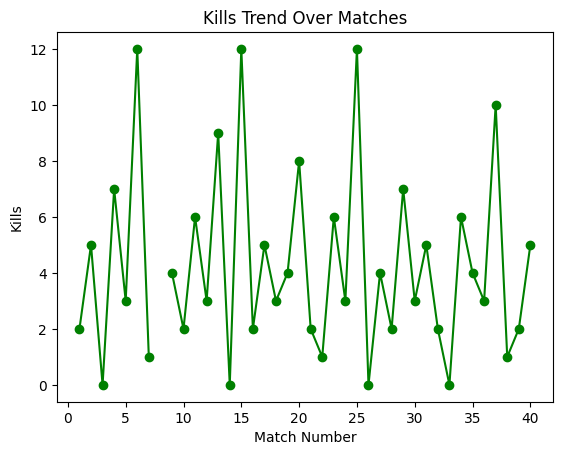

In [19]:
plt.plot(range(1,len(data)+1), data['kills'], marker='o', linestyle='-', color='green')
plt.title('Kills Trend Over Matches')
plt.xlabel('Match Number')
plt.ylabel('Kills')
plt.show()

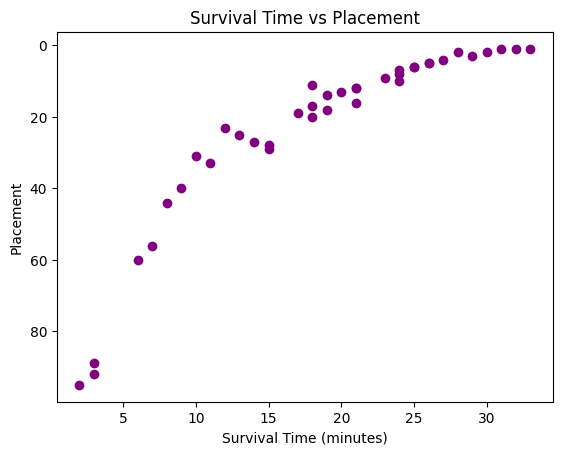

In [20]:
plt.scatter(data['survival_time'], data['placement'], color='purple')
plt.title('Survival Time vs Placement')
plt.xlabel('Survival Time (minutes)')
plt.ylabel('Placement')
plt.gca().invert_yaxis()
plt.show()

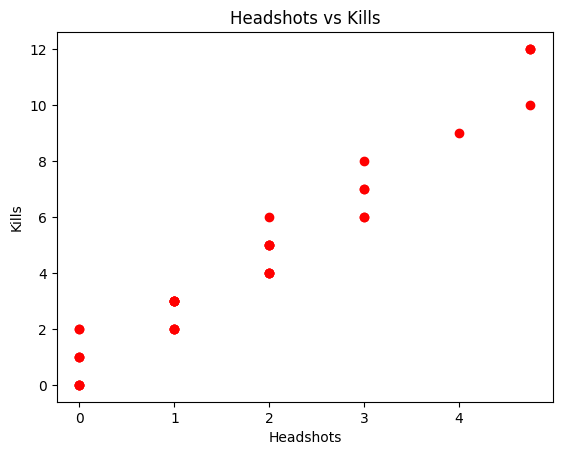

In [21]:
plt.scatter(data['headshots'], data['kills'], color='red')
plt.title('Headshots vs Kills')
plt.xlabel('Headshots')
plt.ylabel('Kills')
plt.show()

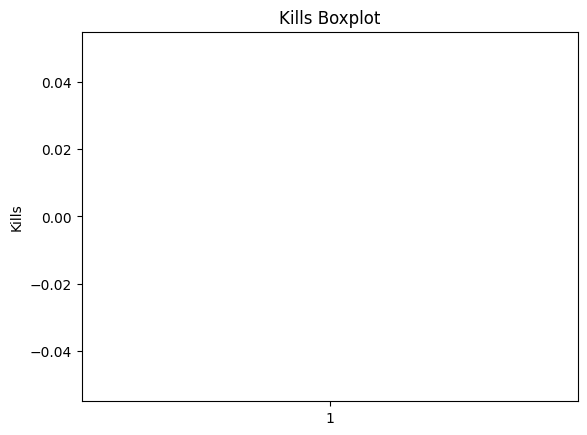

In [22]:
plt.boxplot(data['kills'])
plt.title('Kills Boxplot')
plt.ylabel('Kills')
plt.show()

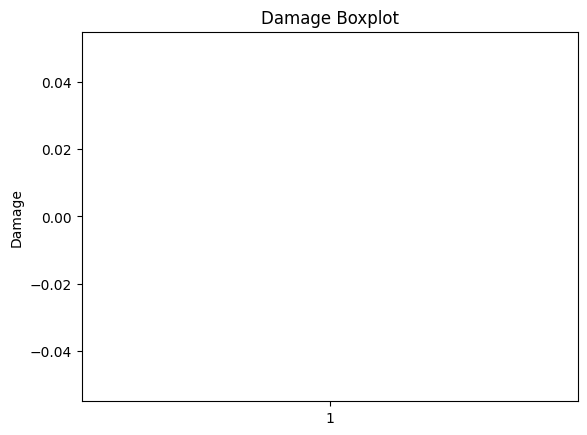

In [23]:
plt.boxplot(data['damage'])
plt.title('Damage Boxplot')
plt.ylabel('Damage')
plt.show()

In [24]:
top_matches = data.sort_values('damage', ascending=False).head(5)
top_matches[['match_id','kills','damage','placement','win']]

,match_id,kills,damage,placement,win
14,15,12.0,1493.75,1.0,1
24,25,12.0,1493.75,1.0,1
5,6,12.0,1450.00,1.0,1
36,37,10.0,1300.00,2.0,0
12,13,9.0,1100.00,3.0,0
